Aadi Kulkarni <br>
02/22/26


# Binary Classifier from scratch
In this notebook, I will be making a binary classification model from scratch ONLY using numpy.

We will be going over the **whole** process of making this model from start to finish with clear explanations.

### What will be covered
- Data generation
- Functions
- Forward pass
- Backward pass
- Gradient Descent
- Training loop
- Inference

We will also be going into the math behind this in depth.

This walkthrough is good if you would like to understand how simple models like a binary classifier work under the hood.

# Imports
In this tutorial, since we are ONLY using math for this, we will only need numpy.
For visualization, we will be used matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
# Random seed set so this notebook replicates the same results no matter what.
random_seed = 67
np.random.seed(random_seed)

# Data Generation

This notebook isn't meant to showcase how to make data, but rather how to make a model that uses it.
For simplicity, we will be using a linearly separable dataset, meaning there exists a linear decision boundary that perfectly separates the two classes in feature space.

### What data does a Binary Classification model need?

A **binary classification model** is made to predict one of two possible classes. The target variable (`y`) must be labeled using two distinct values, generally:

- `0` $\rightarrow$ Negative class or False
- `1` $\rightarrow$ Positive class or True

The model outputs a number between `0` and `1` determining the **probability** that a given input belongs to the **positive class** or `1`. A *threshold* (commonly `0.5`) is typically applied to the model output which will convert this probability into a **discrete class prediction**:

- $\hat{y} \ge 0.5 \;\rightarrow\; 1$
- $\hat{y} < 0.5 \;\rightarrow\; 0$

### Dataset Design

To ensure that the dataset is *intuitive* and easy to visualize, we will use **two** input features for our `X` data. Our `X` array will look like this:

$$
X =
\begin{bmatrix}
x_{11} & x_{12} \\
x_{21} & x_{22} \\
x_{31} & x_{32} \\
\vdots & \vdots \\
x_{n1} & x_{n2}
\end{bmatrix}
$$

Deciding the values for $x_1$ and $x_2$ would go as such:

- $x_1$ $\rightarrow$ Feature 1
- $x_2$ $\rightarrow$ Feature 2

##### Feature 1 ($x_1$)
- Generate **100 samples** from a discrete distribution in the range $[0, 100]$.

##### Feature 2 ($x_2$)
- Generate **100 samples** from a discrete distribution in the range $[0, 300]$.

To determine the `y` data, we will create a simple algorithm where:
$$
y =
\begin{cases}
0 & \text{if } 2x_1 > x_2 \\
1 & \text{otherwise}
\end{cases}
$$



Here is a sample of what our `y` data could look like:
$$
y = \begin{bmatrix}
1 \\
0 \\
1 \\
\vdots \\
0
\end{bmatrix}
$$

This rule creates a perfect linear boundary, which makes this ideal for a **linear classifier**.


In [3]:
# Data gen

def generate_data():
    # Get the random integers
    x1 = np.random.randint(100, size=(100, 1)) # Random from 0-100 x_1
    x2 = np.random.randint(300, size=(100, 1)) # Random from 0-300 x_2
    x = np.concatenate((x1, x2), axis=1) # Merge the two matrices together going from two (100, 1) matrices to one (100, 2) sized matrix

    y = np.where(x[:, 0] * 2 < x[:, 1], 1, 0) # Set `y` equal to 1 or 0 based on condition 2x_1 > x_2
    y = y.reshape(100, 1) # Add another dimension to the matrix to where we change the dimensions from 1D to 2D

    return x, y # Return x matrix and y matrix


In [4]:
x, y = generate_data() # Generation of x and y data using our generate_data function

# Change type of `y` to be f16 instead of int
y = y.astype('float16')

# Dimensions of given matrices
x.shape, y.shape

((100, 2), (100, 1))

Here we will visualize what our data will look like:

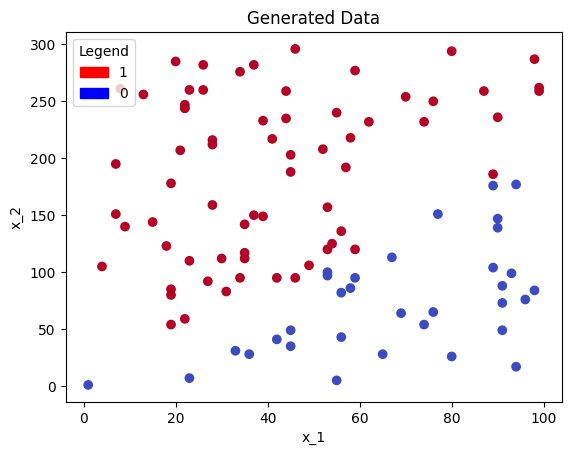

In [5]:
# Visualization of our data in 3 dimensions. x1: x-axis | x2: y-axis | y: color
plt.title('Generated Data')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm')
red_patch = mpatches.Patch(color='red', label='1') # Define custom patch for the legend to signify what red means
blue_patch = mpatches.Patch(color='blue', label='0')    # Define custom patch for the legend to signify what blue means
plt.legend(handles=[red_patch, blue_patch], title="Legend")
plt.show()

# Core Functions

This section contains the mathematical functions for a binary classifier built from scratch, covering the forward pass activations and the backward pass gradients.

---

## 1. Linear Functions
The linear function represents the raw output of a neuron (the "logits") before any non-linear transformation.

* **Function:** `linear(x)`
    * **Formula:** $f(x) = x$
    * **Description:** Returns the input unchanged. Used as the foundation for the weighted sum $wx + b$.
* **Derivative:** `d_linear(x)`
    * **Formula:** $f'(x) = 1$
    * **Description:** The gradient of a linear function is always 1.
    * **Disclaimer:** This function will not be used in our code, it is simply here as a visualization to help us understand it better.

---

## 2. Sigmoid Activation
The Sigmoid function is used to squash the raw linear output into a range between **0 and 1**, which represents the probability of the input belonging to the positive class.

* **Function:** `sigmoid(x)`
    * **Formula:** $\sigma(x) = \frac{1}{1 + e^{-x}}$
    * **Output:** A value $(0, 1)$ representing class probability.
* **Derivative:** `d_sigmoid(x)`
    * **Formula:** $\sigma'(x) = \frac{e^{-x}}{(1 + e^{-x})^2}$
    * **Description:** Calculated during backpropagation to determine how much to update the weights based on the activation's slope.

---

## 3. Binary Cross Entropy (BCE)
Binary Cross Entropy is the loss function used to measure the error between the predicted probability ($\hat{y}$) and the actual label ($y$).

### Loss Function: `BCEloss(y, y_pred)`
**Formula:**
$$L = -\frac{1}{n} \sum [y \log(\hat{y}) + (1 - y) \log(1 - \hat{y})]$$

#### How it works:
BCE is designed to punish the model based on its confidence. It looks at two scenarios:
* **If the true label is 1:** The second half of the formula becomes zero. The loss is strictly $-\log(\hat{y})$. As your prediction ($\hat{y}$) gets closer to 0, the loss grows exponentially toward infinity.
* **If the true label is 0:** The first half becomes zero. The loss is $-\log(1 - \hat{y})$. As your prediction gets closer to 1, the loss explodes.

**The result:** The model is "penalized" lightly for being slightly off, but it is punished severely for being **confidently wrong** (e.g., predicting a 99% probability of Class 1 when the label is actually 0).

* **Stability:** Uses clipping ($1 \times 10^{-15}$) to prevent $\log(0)$, which would result in mathematical errors.

### Gradient: `d_BCEloss(y, y_pred)`
**Formula:**
$$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$

* **Purpose:** This derivative (the *gradient*) tells us the direction and magnitude of change needed. 
    * If $(\hat{y} - y)$ is large, the gradient is large, causing a significant weight update. 
    * The denominator $\hat{y}(1 - \hat{y})$ acts as a scaling factor that accelerates learning when the model is very far from the correct answer.

In [6]:
# functions

def linear(x):
    """
    Linear activation function.
    
    Args:
        x: Numerical input, typically the result of a dot product wx + b.
        
    Returns:
        The input x unchanged.
    """
    return x

def d_linear(x):
    """
    Derivative of linear function (this won't be used at all, it is just here for educational purposes)

    Args:
        x: Numerical input, typically a dot product wx + b
    
    Returns:
        1 (Derivative of x is always 1)
    """
    return np.ones_like(x)

# sigmoid

def sigmoid(x):
    """
    The sigmoid activation function. 1/(1+e^-wx+b). S-shaped curve. Used in logistic regression.

    Args:
        x: Numerical input, typically the returned value from the linear function.

    Returns:
        A probabilistic value between 0 and 1. Indicates the probability an input belongs to a certain class.
    """
    return 1 / (1 + np.exp(-x))

# Derivative of sigmoid

def d_sigmoid(x):
    """
    Derivative of the sigmoid function. e^-x / (1 + e^-x)^2.
    
    Args:
        x: Numerical input, typically the same input passed to the sigmoid function.
        
    Returns:
        The gradient of the sigmoid at point x.
    """
    return (np.exp(-x))/(1+np.exp(-x))**2

# Binary Cross Entropy

def BCEloss(y, y_pred):
    """
    The Binary Cross Entropy loss function. -mean(y * log(y_pred) + (1 - y) * log(1 - y_pred)).
    
    Args:
        y: The ground truth labels (0 or 1).
        y_pred: The predicted probabilities from the sigmoid function.
        
    Returns:
        A single scalar value representing the average loss across all samples.
    """
    e = 1e-15 # Value used to clip 0's incase a divide by 0 occurs
    y_pred = np.clip(y_pred, e, 1 - e)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

# Derivative of Binary Cross Entropy

def d_BCEloss(y, y_pred):
    """
    Derivative of the Binary Cross Entropy loss with respect to y_pred. (y_pred - y) / (y_pred * (1 - y_pred)).
    
    Args:
        y: The ground truth labels (0 or 1).
        y_pred: The predicted probabilities from the sigmoid function.
        
    Returns:
        The gradient of the loss function, used to update weights during backpropagation.
    """
    e = 1e-15 # Value used to clip 0's incase a divide by 0 occurs
    y_pred = np.clip(y_pred, e, 1 - e)
    return (y_pred - y) / (y_pred * (1 - y_pred))



## Parameter Initialization: Weights and Bias

To transform our raw input features ($x_1$ and $x_2$) into a prediction, we must define the learnable parameters of our linear classifier. These parameters define the geometry of the decision boundary within the feature space.

---

### 1. The Weight Vector ($W$)
Since each sample in our dataset $X$ consists of two features, we initialize a weight vector $W \in \mathbb{R}^{2 \times 1}$. Each weight acts as a scaling factor for its corresponding feature:

* $w_1$ scales Feature 1 ($x_1$)
* $w_2$ scales Feature 2 ($x_2$)

By initializing with `np.random.rand(2, 1)`, we break symmetry, ensuring that the model doesn't treat both features identically at the start of training.

### 2. The Bias Term ($b$)
The bias is a scalar parameter $b \in \mathbb{R}$ added to the weighted sum of the inputs. While the weights determine the **angle** of our linear boundary, the bias determines its **offset** from the origin. 

### 3. Functional Interaction with Data
The model processes the input data through a linear transformation. Given our input matrix $X$ (size $n \times 2$), the interaction is calculated as a matrix-vector product:

$$z = XW + b$$

Expanding this for a single observation $(x_1, x_2)$, the operation is:

$$z = (x_1 \cdot w_1 + x_2 \cdot w_2) + b$$

### 4. Correlation to the Decision Boundary
In our data generation, we defined the target $y$ based on the rule $2x_1 > x_2$, which can be rewritten as the inequality:

$$2x_1 - x_2 + 0 > 0$$

Our model’s goal is to learn a set of parameters $(w_1, w_2, b)$ such that:
* $w_1 \approx 2$
* $w_2 \approx -1$
* $b \approx 0$

When the model successfully learns these values, the sign of $z$ will perfectly correlate with our generated classes, allowing the model to accurately separate the two groups in the $300 \times 100$ feature space.

In [7]:
# Initialization of weights and biases
w = np.random.rand(2, 1) # Random initialization of weights with a maxtrix size of (2, 1)
b = np.ones((1,)) # Bias initialization with a matrix size of (1,)

w,b

(array([[0.62166734],
        [0.62316299]]),
 array([1.]))

# Forward Pass:

The forward pass is the process of moving input data through the network layers to calculate a prediction and evaluate its accuracy.

### 1. Linear Transformation (The "Logit")
`z = linear(np.dot(x, w) + b)`
* **The Math:** calculates the weighted sum $z = \sum (x_i w_i) + b$.
* **What's happening:** The model takes the input features (`x`), multiplies them by their respective weights (`w`), and adds a bias (`b`). This represents the "raw score" for a class.
* **Output:** A real number (can be any value from $-\infty$ to $+\infty$).

### 2. Probabilistic Activation
`y_pred = sigmoid(z)`
* **The Math:** $\hat{y} = \sigma(z)$
* **What's happening:** We pass the raw score `z` through the Sigmoid function to "squash" it.
* **Output:** A value between **0 and 1**. This is interpreted as the **probability** that the input belongs to the positive class (e.g., $0.85$ means an 85% confidence that the label is 1).

### 3. Error Evaluation
`loss = BCEloss(y, y_pred)`
* **The Math:** Calculating the distance between $\hat{y}$ and the ground truth $y$.
* **What's happening:** The model compares its prediction against the actual answer. If the prediction is close to the truth, the loss is small; if the prediction is far from the truth, the loss is large.
* **Output:** A **single scalar value**. This number tells us "how wrong" the model is. In training, our goal is to minimize this value using backpropagation.

---

### Example Output
If you run this code, the variable `loss` will return a float:<br>
**Output:** `0.2341`

* **Low Loss (e.g., 0.05):** The model's predictions are very close to the actual labels.
* **High Loss (e.g., 2.50):** The model is frequently wrong or very unconfident in its correct answers.
---
### Interpreting the Model Output

Upon running the forward pass with our current parameters, we see the following result:

$$L \approx 10.92$$

#### Why is the loss so high?
A loss value of **10.92** is significantly high for Binary Cross Entropy. This result is expected at this stage for two primary reasons:

1.  **Random Initialization:** Our weights ($w$) and biases ($b$) were initialized using random values. Because the model hasn't "seen" the patterns in the data yet, its initial predictions are essentially stabs in the dark.
2.  **Confident Incorrectness:** In BCE, a loss this high suggests the model isn't just wrong; it’s **confidently wrong**. It is likely predicting values close to $0$ for samples where the true label is $1$ (or vice versa), triggering the logarithmic penalty.


In [8]:
# forward pass

z = linear(np.dot(x, w) + b) # Pass the dot product through the linear function, gives us the output neuron.
y_pred = sigmoid(z) # Apply activation onto the output, returns value between 0-1
loss = BCEloss(y, y_pred) # Find the loss

loss

10.927328764002155

# The Backward Pass:

In our forward pass, the model used random guesses for $w_1$ and $w_2$ to try and learn the rule $2x_1 > x_2$. With an initial loss of $L \approx 10.92$, the model is struggling. The **backward pass** is how the model mathematically "looks" at the features $x_1$ and $x_2$ to correct its internal logic.

### 1. The Chain Rule & Gradient Movement
To update the weights, we need to find the gradient of the loss with respect to those weights. We use the **Chain Rule** to multiply the derivatives of each step in the forward pass:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial z} \times \frac{\partial z}{\partial w}$$

In the code, we explicitly calculate each step to visualize how the error flows backward:

* **`dBCE_dpred`**: $\frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$ — This measures how far our predicted probability was from the truth.
* **`dsig_dz`**: $\frac{e^{-z}}{(1 + e^{-z})^2}$ — This captures the "sensitivity" of the sigmoid function at the current input $z$.
* **`dLoss_d_w`**: We multiply these together (`dBCE_dpred * dsig_dz`) to find the gradient with respect to $z$. 

> **Note on Implementation:** In optimized libraries, these terms often "cancel out" to a simple $(\hat{y} - y)$. However, in our code, we **do not cancel them out**. We keep them separate so you can clearly see the flow of gradients through every mathematical function we defined.

---

### 2. Tying Error to Features ($x_1, x_2$)
The gradient for the weights (`dw`) is calculated by multiplying the error by the input features:
`dw = x.T.dot(dLoss_d_w) / x.shape[0]`

**How this fixes our data separation:**
* Assume a data point where $x_1=80, x_2=20$. Per our rule ($2x_1 > x_2$), the label $y$ is **0**.
* If the model incorrectly predicts a high probability ($\hat{y} = 0.9$), the error is large.
* The math multiplies this error by the specific feature values ($x_1=80, x_2=20$). This creates a **large gradient** specifically for $w_1$, signaling to the model: *"Your weight for $x_1$ is too high; it is pushing the prediction toward '1' when it should be '0'."*

---

### 3. The Update

After calculating `dw` and `db` (the average gradients across all 100 samples), we update our parameters. This process relies on a mathematical concept called **Linear Approximation**.

#### What is Linear Approximation?
In complex models, the "Loss Landscape" is a curvy, hilly surface. It is difficult to know exactly where the bottom of the hill is. However, if we zoom in close enough to any single point on that curve, the surface looks like a **flat, straight line (a tangent)**. 

By calculating the derivative, we find the slope of that straight line. Linear approximation allows us to say: *"If I move a tiny distance in the direction of this slope, I can predict how much the loss will change."*

### From Linear Approximation to the Update Rule

To understand why we subtract the gradient, we look at the **first order Taylor approximation**. This formula predicts what the Loss ($L$) will be if we change our weights ($w$) by a tiny amount ($\Delta w$):

$$L(w + \Delta w) \approx L(w) + L'(w)\Delta w$$

#### The Derivation Steps:

1. **The Goal**: We want the new loss $L(w + \Delta w)$ to be **smaller** than our current loss $L(w)$. 
   Mathematically, this means we need the change to be negative:
   $$L'(w)\Delta w < 0$$

2. **Choosing the Direction**: To make sure that $L'(w)\Delta w$ is always negative, we can set our change ($\Delta w$) to be the negative of the gradient ($L'(w)$). 
   Why? Because any number multiplied by its own negative (e.g., $x \cdot -x$) results in a negative value (or zero).
   $$\Delta w = -L'(w)$$

3. **Controlling the Step**: As mentioned, linear approximation is only accurate in a tiny neighborhood. If we move too far, the "straight line" no longer matches the "curve." We introduce the **Learning Rate ($\alpha$)** to keep the step small:
   $$\Delta w = -\alpha \cdot L'(w)$$

4. **Final Gradient Descent Formula**: By substituting $\Delta w$ back into our weight formula ($w_{new} = w_{old} + \Delta w$), we arrive at the standard Gradient Descent update:
   $$w_{new} = w_{old} - \alpha \cdot dw$$


In [9]:
# backward pass

dBCE_dpred = d_BCEloss(y, y_pred) # Find gradient of the loss function w.r.t. predictions
dsig_dz = d_sigmoid(z) # Gradient of sigmoid at point z
dLoss_d_w = dBCE_dpred * dsig_dz # Find gradient w.r.t. z

dw = x.T.dot(dLoss_d_w) / x.shape[0] # Find average gradient of the weights
db = np.sum(dLoss_d_w) / x.shape[0] # Find average gradient of the bias


# The Training Loop & Final Convergence

The training loop is the "engine room" of the model. This is where the forward and backward passes are repeated thousands of times, allowing the model to slowly refine its weights and biases through iterative learning.

### 1. Loop Hyperparameters
* **Epochs (`20,000`):** An epoch is one full pass through the dataset. We repeat this thousands of times because each individual update is tiny. The model needs these "practice rounds" to move the weights from random noise to a meaningful decision boundary.
* **Learning Rate (`lr = 0.01`):** This defines our step size. We keep it small to ensure our **linear approximation** remains valid, preventing the model from "overshooting" the minimum loss and failing to converge.

---

### 2. The Iterative Process
Inside the loop, the code executes the core parts of machine learning:
1.  **Prediction:** The model performs a forward pass to generate `y_pred`.
2.  **Evaluation:** It measures the error using `BCEloss`.
3.  **Backpropagation:** It calculates the gradients (`dw`, `db`) to identify how to reduce the error.
4.  **The Update:** It applies **Gradient Descent**, slightly moving the parameters in the opposite direction of the error.

---

### 3. Analyzing the Training Outputs
Upon completion, the model produces a set of numbers that tells you what it learned after training:

#### The Loss Progression
* **Epoch 0 (`10.9273`):** The model is "confidently wrong." The random initialization resulted in a high penalty.
* **Epoch 15000 (`0.0078`):** The loss has plummeted. This confirms that our **Linear Approximation** worked—by following the slope of the loss, the model successfully found the "bottom of the hill."

#### Final Parameters & Gradients

**Final Results:**
* **Final Loss:** `0.0064`
* **Weights ($w$):** `[[-2.169], [1.080]]`
* **Bias ($b$):** `[0.273]`
* **Gradients ($dw$):** `[[0.0036], [-0.0018]]`

**The Weight Ratio:**
Our data generation rule was $2x_1 > x_2$. Notice the resulting weights: **-2.169** and **1.080**. The ratio between them is approximately **2:1**. This confirms the model successfully "discovered" our  logic that $x_1$ is twice as significant as $x_2$ in determining the class, and they have opposite impacts on the outcome.

**Vanishing Gradients:**
The final gradients ($dw, db$) are now nearly zero. This indicates that the slope of the loss landscape is flat; the model has reached the optimum point where taking further steps will no longer significantly reduce the loss. This is the signal that training is complete.

In [ ]:
# training loop

epochs = 20000 # Training iterations
lr = 0.01 # How much our model "adjusts" by per iteration

loss_hist = [] # A way to track our losses

for i in range(epochs):
    z = linear(np.dot(x, w) + b) # Start of forward pass
    y_pred = sigmoid(z)

    loss = BCEloss(y, y_pred) # End of forward pass

    dBCE_dpred = d_BCEloss(y, y_pred) # Start of backward pass
    dsig_dz = d_sigmoid(z)
    dLoss_d_w = dBCE_dpred * dsig_dz

    dw = x.T.dot(dLoss_d_w) / x.shape[0] # Gradient of weights
    db = np.sum(dLoss_d_w) / x.shape[0] # Gradient of bias

    w -= lr * dw # Gradient Descent updating weights
    b -= lr * db # Gradient Descent updating bias

    loss_hist.append(loss) # Add current loss to our loss history

    if i % 5000 == 0:
        print(f"Epoch {i}: {BCEloss(y,y_pred):.4f}") # Show progress every 5000 training iterations

print('Training complete!')
print(loss)
print(w, b, dw, db)

Epoch 0: 10.9273
Epoch 5000: 0.0132
Epoch 10000: 0.0098
Epoch 15000: 0.0078
Training complete!
0.006404653729200634
[[-2.16905681]
 [ 1.0809417 ]] [0.27346499] [[ 0.00362584]
 [-0.00183156]] 0.0025296197700261365


### Loss history over epochs
This graph shows how the loss minimizes as the model learns from the data. It shows the change over each epoch. We can see this goes down over time, proving our model was learning.

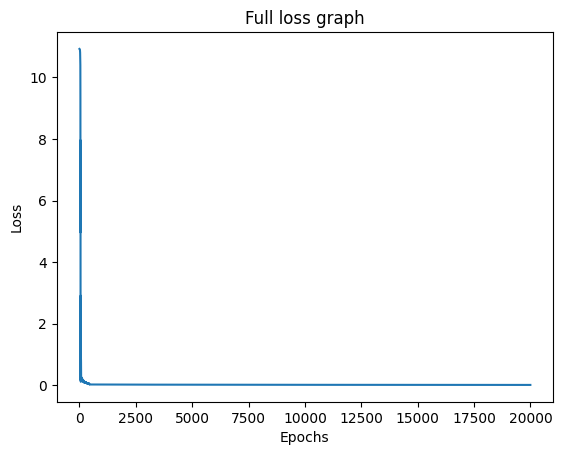

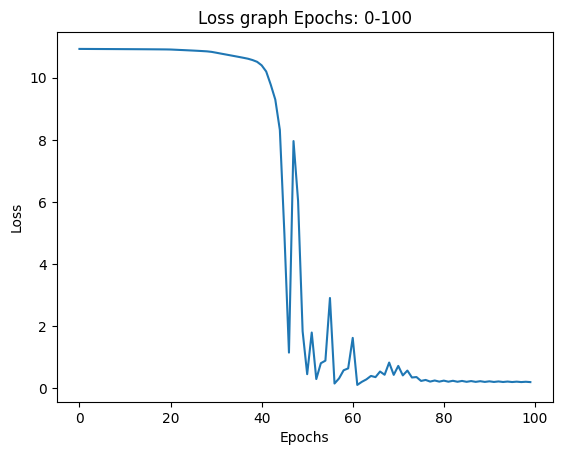

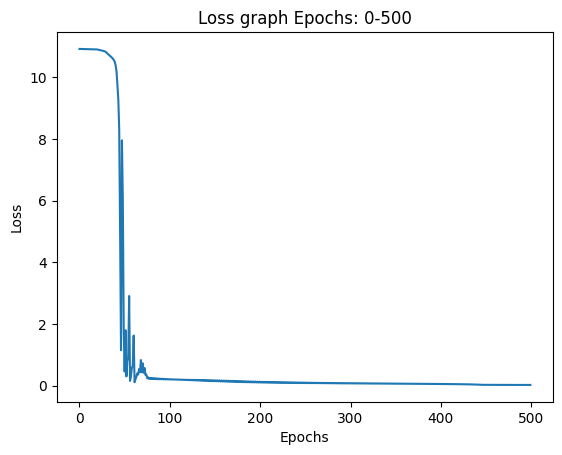

In [11]:
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.title('Full loss graph')
plt.plot(range(epochs), loss_hist)

plt.show()

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.title('Loss graph Epochs: 0-100')
plt.plot(range(epochs)[:100], loss_hist[:100])
plt.show()

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.title('Loss graph Epochs: 0-500')
plt.plot(range(epochs)[:500], loss_hist[:500])
plt.show()


### Inference:
Inference is the process of using our trained model to make a prediction on new data. It does a single **forward pass** using the trained weights and bias to calculate a probability.

### Analyzing the Result
For the input `[85, 159]`, the model outputs: `4.89e-06`.

* **The Probability:** This value is approximately **0.0000049**, which is nearly zero. 
* **The Confidence:** This indicates the model is extremely confident the label is **0** (the probability of it being **1** is almost non-existent).
* **Data Logic:** This matches our rule ($2x_1 > x_2$) perfectly. Since $2(85)$ is $170$, and $170 > 159$, the correct label is indeed **0**. Our model has accurately translated the data logic into a prediction.

In [12]:
# Inference function

def predict(x, w, b):
    z = linear(np.dot(x, w) + b)
    return sigmoid(z)

print(predict([85, 159], w, b))

[4.8982189e-06]


### Visualizing the Loss Landscape

The **Loss Landscape** is a "map" that shows the error for every possible combination of weights. This function generates the data needed to visualize the "valley" our model just descended.

* **Centering the Map:** The function uses our trained weights (`w1`, `w2`) as the center point. It then looks at a specific `scale` (distance) around them to see how the loss increases in every direction.
* **Creating the Grid:** It builds a coordinate system (`grid`) by testing different weight values. For every point on this grid, it runs a forward pass to see what the `BCEloss` would have been.
* **The Goal:** This creates a 3D surface or contour plot. The "bottom" of the bowl represents our optimized weights, where the loss is lowest, while the "walls" represent higher error.

By generating this landscape, we can visually confirm that our model successfully found the lowest point (the global minimum) of the error surface.

In [13]:
def find_loss(w1, w2, b, X, y):
    w = np.array([[w1], [w2]])
    y_pred = predict(X, w, b)
    return BCEloss(y, y_pred)

def hx(a, b, N):
    return (b - a)/(N - 1)

def generate_loss_landscape(resolution, scale):
    # Initializations
    w1_s = w[0][0]
    w2_s = w[1][0]
    b_s = b.copy()
    delta = scale
    N = resolution

    # Computations for coefficients
    a1 = w1_s - delta 
    b1 = w1_s + delta
    h1 = hx(a1, b1, N)
    a2 = w2_s - delta
    b2 = w2_s + delta
    h2 = hx(a2, b2, N)

    # Initialize empty grid
    grid = np.zeros((N, N))

    # Fill grid with loss values
    for i in range(N):
        for j in range(N):

            w1_n = a1 + (j * h1)
            w2_n = a2 + (i * h2)
            grid[i][j] = find_loss(w1_n, w2_n, b_s, x, y)

    w1_values = np.array([a1 + j*h1 for j in range(N)])
    w2_values = np.array([a2 + i*h2 for i in range(N)])
    return grid, w1_values, w2_values

### Reading the Loss Landscape

These heatmaps provide a visualization for what our model sees. By looking at different zoom levels (scales), we can see exactly how the loss changes as we deviate from our final weights.

* **The Zoom Levels (1.5x, 0.5x, 0.01x):**
    * **1.5x (Wide View):** Shows the overall "valley" of the loss. Notice the high yellow values (Loss > 20) at the edges, this is where the model would be if we hadn't trained it.
    * **0.5x (Mid View):** We are zooming in closer to our center point. The range of loss is much smaller here.
    * **0.01x (Micro View):** A microscopic look at our final weights. Even at this scale, the loss is tiny (around `0.007`), proving we are at a very stable point.

* **The Purple "Trench":**
    The dark purple line represents the **Global Minimum**. In our case, it looks like a long diagonal trench rather than a single hole. This is because there are multiple combinations of $w_1$ and $w_2$ that can represent the ratio $2x_1 > x_2$. Any coordinate sitting in that dark purple zone results in near-zero error AND accurate predictions.

* **Finding the Minimum:**
    Our final trained weights are at the exact center of these plots. Since the centers are consistently purple, it proves that our **Gradient Descent** successfully navigated the model into the bottom of the valley.

### 1x Contour Plot
The contour plot at the bottom uses colored "steps" to show elevation.
* **The Gradient:** The closer the lines are to each other, the steeper the "hill." 
* **Optimal Zone:** The wide, dark purple area at the top-right shows the region where the model performs perfectly. By getting our weights here, we have ensured the model has a high level of accuracy and confidence.

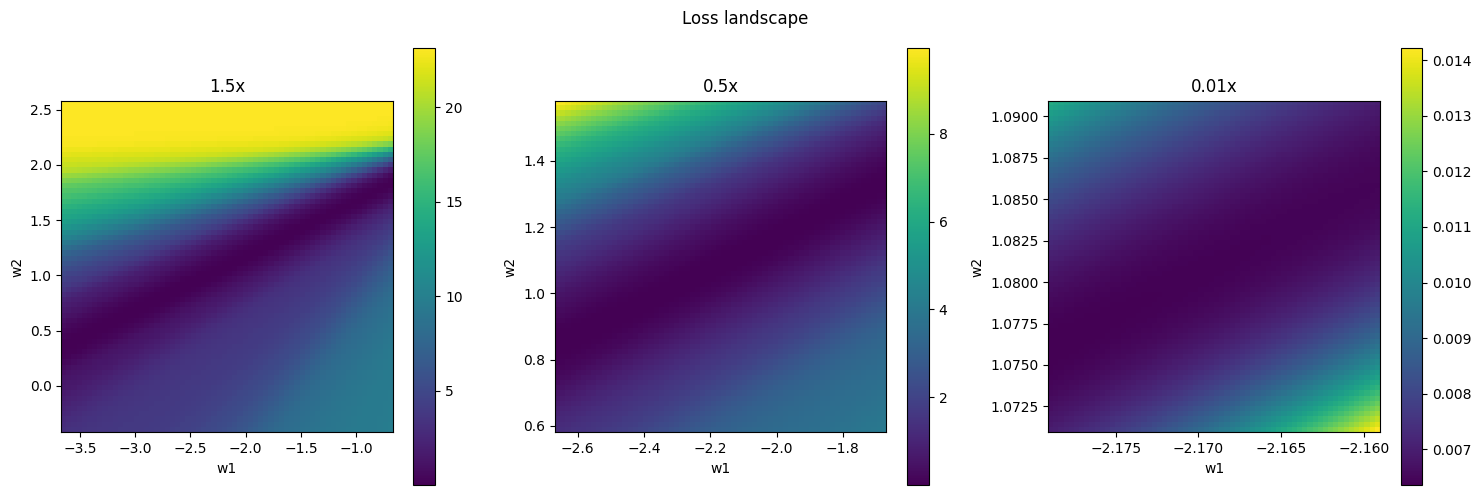

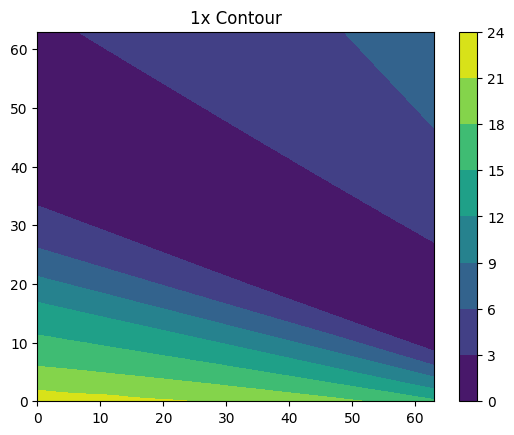

In [24]:
plt.figure(figsize=(15, 5))
plt.suptitle('Loss landscape')

plt.subplot(1, 3, 1)
ls, w1_vals, w2_vals = generate_loss_landscape(64, 1.5)
plt.imshow(ls, extent=[min(w1_vals), max(w1_vals), min(w2_vals), max(w2_vals)])
plt.xlabel('w1')
plt.ylabel('w2')
plt.colorbar()
plt.title('1.5x')

plt.subplot(1, 3, 2)
ls, w1_vals, w2_vals = generate_loss_landscape(64, 0.5)
plt.imshow(ls, extent=[min(w1_vals), max(w1_vals), min(w2_vals), max(w2_vals)])
plt.xlabel('w1')
plt.ylabel('w2')
plt.colorbar()
plt.title('0.5x')

plt.subplot(1, 3, 3)
ls, w1_vals, w2_vals = generate_loss_landscape(64, 0.01)
plt.imshow(ls, extent=[min(w1_vals), max(w1_vals), min(w2_vals), max(w2_vals)])
plt.xlabel('w1')
plt.ylabel('w2')
plt.colorbar()
plt.title('0.01x')

plt.tight_layout()
plt.show()

# Show contour:
ls, w1_vals, w2_vals = generate_loss_landscape(64, 1)
plt.contourf(ls)
plt.colorbar()
plt.title('1x Contour')
plt.show()


### Visualizing the Decision Boundary

This scatter plot displays our **Test Data**, representing 100 new samples the model hasn't seen during training. It serves as the final "exam" for our classifier.

* **Data Separation:** You can see a clear diagonal split between the **Red dots (1)** and **Blue dots (0)**. This confirms our rule ($2x_1 > x_2$) creates a linearly separable dataset.
* **The Model's Task:** For the model to succeed, its learned weights must define a mathematical line that passes exactly through that empty space between the two colors.
* **Success Indicator:** Because the clusters are distinct with no overlapping points, our model should be able to achieve a near **100% accuracy** on this test set, perfectly predicting the color of every dot based solely on its $x_1$ and $x_2$ coordinates.

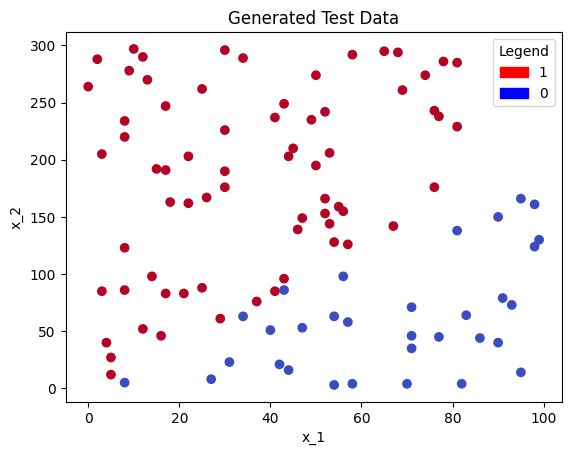

In [15]:
# Test
x_test, y_test = generate_data()

plt.title('Generated Test Data')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='coolwarm')
red_patch = mpatches.Patch(color='red', label='1')
blue_patch = mpatches.Patch(color='blue', label='0')
plt.legend(handles=[red_patch, blue_patch], title="Legend")
plt.show()

### Final Evaluation:

This final step visualizes the "mental map" the model has constructed. We compare the **Actual Test Data** (the ground truth) against the **Evaluated Test Data** (the model's predictions).

* **The Lime Green Line:** This is the **Decision Boundary**. Mathematically, it represents the exact threshold where the model’s prediction is $0.5$. The `find_decision_boundary` function extracts this line by rearranging our linear equation $z = w_1x_1 + w_2x_2 + b = 0$ to solve for $x_2$ (as that is our y_axis).
* **Perfect Classification:** In the "Evaluated Test Data" plot, every single red dot is above the green line and every blue dot is below it. This proves that our model has achieved **100% accuracy** on the test set.
* **Rounding to Classes:** Note the use of `np.round()`. This converts the model's raw probabilities (like `0.99` or `0.00004`) into discrete classes (`1` or `0`). 

### Conclusion
By comparing the two plots, we can see they are identical. The lime green line perfectly mimics our original data rule ($2x_1 > x_2$). Through 20,000 epochs of training, the model successfully found the logic of the dataset using nothing but calculus.

In [16]:
# prediction
predicted_labels = np.round(predict(x_test, w, b))

In [17]:
def find_decision_boundary(w, b, x):
    x2 = (((-w[0]) / w[1]) * x) - (b[0] / w[1])
    return x2

def actual_decision_boundary():
    x1 = np.linspace(0, 100, 100)
    x2 = 2 * x1
    return x1, x2

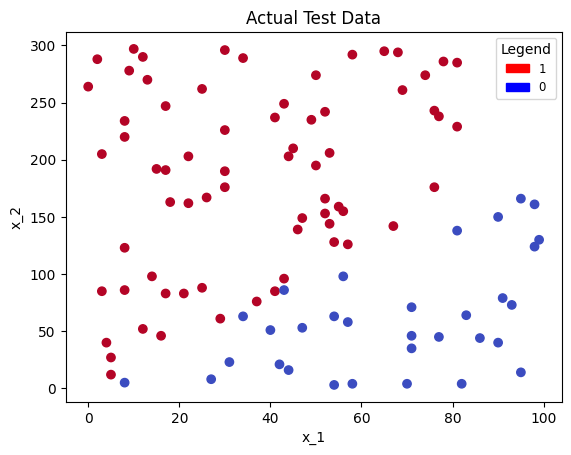

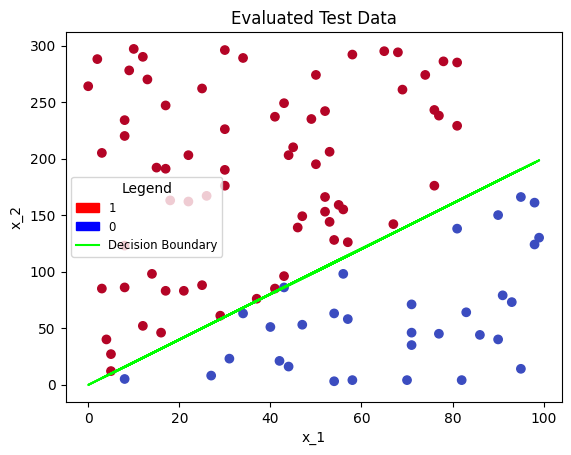

Sample of predicted:
 [[0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [18]:
# Predicting test data values, compare it to actual values



plt.title('Actual Test Data')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='coolwarm')
red_patch = mpatches.Patch(color='red', label='1')
blue_patch = mpatches.Patch(color='blue', label='0')
plt.legend(handles=[red_patch, blue_patch], title="Legend", fontsize='small')
plt.show()

plt.title('Evaluated Test Data')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.scatter(x_test[:, 0], x_test[:, 1], c=predicted_labels, cmap='coolwarm')
red_patch = mpatches.Patch(color='red', label='1')
blue_patch = mpatches.Patch(color='blue', label='0')
line_handle, = plt.plot(x_test[:, 0], find_decision_boundary(w, b, x_test[:, 0]), color='lime', label='Decision Boundary')
plt.legend(handles=[red_patch, blue_patch, line_handle], title="Legend", fontsize='small')

plt.show()

print(f'Sample of predicted:\n {predicted_labels[:10]}')

Proof of a perfect model :)

In [19]:
# Evaluate accuracy
correct = 0

for i in range(len(predicted_labels)):
    correct += 1 if predicted_labels[i] == y_test[i] else 0

accuracy = (correct / len(y_test)) * 100

print(f'Model scored an accuracy of {accuracy}%')

Model scored an accuracy of 100.0%


### Overall Performance Validation

To prove the model didn't just "memorize" the first set of data, we test it against **10 completely new batches** of generated data.

* **Consistency:** The model maintains nearly **100% accuracy** across 1,000 new random points (10 batches of 100).
* **Generalization:** Because the accuracy stays high on data it has never seen before, we know the model successfully learned the **rule** ($2x_1 > x_2$) rather than just the specific training examples.
* **The 99.9% Result:** A minor "miss" (like the 99.0% in Batch 6) usually occurs when a data point lands exactly on the decision boundary line, where the probability is virtually 50/50.

In [20]:
# overall

batches = 10
percents = []

for i in range(batches):
    correct = 0
    g, gy = generate_data()
    at = np.round(predict(g, w, b))
    for j in range(len(predicted_labels)):
        correct += 1 if at[j] == gy[j] else 0

    percents.append((correct / len(gy))* 100)
    print(f'Accuracy for batch {i + 1}: {percents[i]}')

print(f'Total accuracy across {batches} batches: {np.mean(percents)}%')


Accuracy for batch 1: 100.0
Accuracy for batch 2: 100.0
Accuracy for batch 3: 100.0
Accuracy for batch 4: 100.0
Accuracy for batch 5: 100.0
Accuracy for batch 6: 99.0
Accuracy for batch 7: 100.0
Accuracy for batch 8: 100.0
Accuracy for batch 9: 100.0
Accuracy for batch 10: 100.0
Total accuracy across 10 batches: 99.9%


### True vs. Model's Decision Boundary

This final visualization is to compare the **Model's Learned Boundary** (Lime Green) against the **Actual Mathematical Rule** (Black Dashed Line).

* **Perfect Alignment:** The two lines are nearly identical and perfectly overlap.
* **Final Result:** The overlap confirms that our use of the Chain Rule, Sigmoid activation, and Gradient Descent was successful. The model has reached the theoretical limit of how well it can perform on this task.

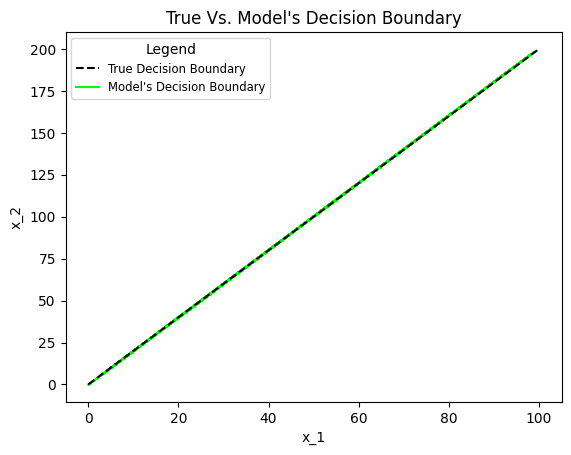

In [21]:
# predicted decision boundary vs actual
line_x, line_y = actual_decision_boundary()
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.title("True Vs. Model's Decision Boundary")
line_handle2, = plt.plot(x_test[:, 0], find_decision_boundary(w, b, x_test[:, 0]), color='lime', label="Model's Decision Boundary")
line_handle1, = plt.plot(line_x, line_y, 'k--', label='True Decision Boundary')
plt.legend(handles=[line_handle1, line_handle2], title="Legend", fontsize='small')
plt.show()

**Thank you** for following along with this breakdown! I hope this helped you visualize how the math actually translates into a working model AND I hope you can use this as a great starting point when continuing your journey in AI.